In [3]:
import numpy as np

np.random.seed(42)
X = np.random.randn(100, 3)
y = np.random.randint(0, 2, size=(100, 1)).astype(float)

batch_size = 32
learning_rate = 0.1
epochs = 3

W = np.random.randn(3, 1) * 0.01
b = np.zeros((1, 1))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for epoch in range(epochs):
    permutation = np.random.permutation(X.shape[0])
    X_shuffled = X[permutation]
    y_shuffled = y[permutation]

    print(f"Epoch {epoch+1}")
    for i in range(0, X.shape[0], batch_size):
        X_batch = X_shuffled[i : i + batch_size]
        y_batch = y_shuffled[i : i + batch_size]

        Z = np.dot(X_batch, W) + b
        A = sigmoid(Z)

        m_batch = X_batch.shape[0]
        dZ = A - y_batch
        dW = np.dot(X_batch.T, dZ) / m_batch
        db = np.sum(dZ, axis=0, keepdims=True) / m_batch

        W -= learning_rate * dW
        b -= learning_rate * db

        print(f" Indices: {i} to {i+m_batch}")


Epoch 1
 Indices: 0 to 32
 Indices: 32 to 64
 Indices: 64 to 96
 Indices: 96 to 100
Epoch 2
 Indices: 0 to 32
 Indices: 32 to 64
 Indices: 64 to 96
 Indices: 96 to 100
Epoch 3
 Indices: 0 to 32
 Indices: 32 to 64
 Indices: 64 to 96
 Indices: 96 to 100


SGD with Momentum Optimizer From Scratch


In [4]:
import numpy as np

np.random.seed(42)
X = np.random.randn(100, 3)
y = np.random.randint(0, 2, size=(100, 1)).astype(float)

batch_size = 32
learning_rate = 0.1
epochs = 3

W = np.random.randn(3, 1) * 0.01
b = np.zeros((1, 1))

v_W = np.zeros_like(W)
v_b = np.zeros_like(b)
beta = 0.9

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for epoch in range(epochs):
    permutation = np.random.permutation(X.shape[0])
    X_shuffled = X[permutation]
    y_shuffled = y[permutation]

    print(f"Epoch {epoch+1}")
    for i in range(0, X.shape[0], batch_size):
        X_batch = X_shuffled[i : i + batch_size]
        y_batch = y_shuffled[i : i + batch_size]

        Z = np.dot(X_batch, W) + b
        A = sigmoid(Z)

        m_batch = X_batch.shape[0]
        dZ = A - y_batch
        dW = np.dot(X_batch.T, dZ) / m_batch
        db = np.sum(dZ, axis=0, keepdims=True) / m_batch

        v_W = beta * v_W + (1 - beta) * dW
        v_b = beta * v_b + (1 - beta) * db

        W -= learning_rate * v_W
        b -= learning_rate * v_b

        print(f" Indices: {i} to {i+m_batch}")


Epoch 1
 Indices: 0 to 32
 Indices: 32 to 64
 Indices: 64 to 96
 Indices: 96 to 100
Epoch 2
 Indices: 0 to 32
 Indices: 32 to 64
 Indices: 64 to 96
 Indices: 96 to 100
Epoch 3
 Indices: 0 to 32
 Indices: 32 to 64
 Indices: 64 to 96
 Indices: 96 to 100


The Adam

In [5]:
import numpy as np

np.random.seed(42)
X = np.random.randn(100, 3)
y = np.random.randint(0, 2, size=(100, 1)).astype(float)

batch_size = 32
learning_rate = 0.01
epochs = 3

W = np.random.randn(3, 1) * 0.01
b = np.zeros((1, 1))

m_W, v_W = np.zeros_like(W), np.zeros_like(W)
m_b, v_b = np.zeros_like(b), np.zeros_like(b)

beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8
t = 0

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for epoch in range(epochs):
    permutation = np.random.permutation(X.shape[0])
    X_shuffled = X[permutation]
    y_shuffled = y[permutation]

    print(f"Epoch {epoch+1}")
    for i in range(0, X.shape[0], batch_size):
        X_batch = X_shuffled[i : i + batch_size]
        y_batch = y_shuffled[i : i + batch_size]

        Z = np.dot(X_batch, W) + b
        A = sigmoid(Z)

        m_batch = X_batch.shape[0]
        dZ = A - y_batch
        dW = np.dot(X_batch.T, dZ) / m_batch
        db = np.sum(dZ, axis=0, keepdims=True) / m_batch

        t += 1

        m_W = beta1 * m_W + (1 - beta1) * dW
        m_b = beta1 * m_b + (1 - beta1) * db

        v_W = beta2 * v_W + (1 - beta2) * (dW ** 2)
        v_b = beta2 * v_b + (1 - beta2) * (db ** 2)

        m_W_corrected = m_W / (1 - beta1 ** t)
        m_b_corrected = m_b / (1 - beta1 ** t)
        v_W_corrected = v_W / (1 - beta2 ** t)
        v_b_corrected = v_b / (1 - beta2 ** t)

        W -= (learning_rate / (np.sqrt(v_W_corrected) + epsilon)) * m_W_corrected
        b -= (learning_rate / (np.sqrt(v_b_corrected) + epsilon)) * m_b_corrected

        print(f" Indices: {i} to {i+m_batch}")


Epoch 1
 Indices: 0 to 32
 Indices: 32 to 64
 Indices: 64 to 96
 Indices: 96 to 100
Epoch 2
 Indices: 0 to 32
 Indices: 32 to 64
 Indices: 64 to 96
 Indices: 96 to 100
Epoch 3
 Indices: 0 to 32
 Indices: 32 to 64
 Indices: 64 to 96
 Indices: 96 to 100


Weight Initialization Techniques

In [6]:
import numpy as np

np.random.seed(42)
input_neurons = 100
hidden_neurons = 50

Xavier_W = np.random.randn(input_neurons, hidden_neurons) * np.sqrt(1.0 / input_neurons)

He_W = np.random.randn(input_neurons, hidden_neurons) * np.sqrt(2.0 / input_neurons)

print("Xavier Variance:", np.var(Xavier_W))
print("He Variance:", np.var(He_W))


Xavier Variance: 0.009927734548371578
He Variance: 0.020415578107496692


Batch Normalization

In [7]:
import numpy as np

np.random.seed(42)
N, D = 32, 4
Z = np.random.randn(N, D) * 5 + 2

gamma = np.ones((1, D))
beta = np.zeros((1, D))
epsilon = 1e-5

mu = np.mean(Z, axis=0, keepdims=True)
var = np.var(Z, axis=0, keepdims=True)

Z_norm = (Z - mu) / np.sqrt(var + epsilon)
Z_tilde = gamma * Z_norm + beta

print("Original Mean:", np.mean(Z, axis=0))
print("Normalized Mean:", np.mean(Z_norm, axis=0))
print("Final Batch Norm Output Shape:", Z_tilde.shape)


Original Mean: [1.45191971 1.64310168 1.65557089 1.93734206]
Normalized Mean: [-6.93889390e-17  0.00000000e+00 -5.89805982e-17  9.02056208e-17]
Final Batch Norm Output Shape: (32, 4)


Dropout Regularization From Scratch

In [8]:
import numpy as np

np.random.seed(42)
A1 = np.random.randn(5, 4)
keep_prob = 0.7

mask = (np.random.rand(*A1.shape) < keep_prob).astype(int)
A1_dropped = A1 * mask
A1_scaled = A1_dropped / keep_prob

print("Original Hidden Layer Matrix:\n", A1)
print("\nActive Neurons Mask (1=Keep, 0=Drop):\n", mask)
print("\nFinal Scaled Dropout Output:\n", A1_scaled)


Original Hidden Layer Matrix:
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024 -1.72491783 -0.56228753]
 [-1.01283112  0.31424733 -0.90802408 -1.4123037 ]]

Active Neurons Mask (1=Keep, 0=Drop):
 [[1 0 1 1]
 [1 1 1 1]
 [1 0 0 0]
 [1 1 1 1]
 [1 1 1 0]]

Final Scaled Dropout Output:
 [[ 0.70959165 -0.          0.92526934  2.17575694]
 [-0.33450482 -0.33448137  2.25601831  1.09633533]
 [-0.67067769  0.         -0.         -0.        ]
 [ 0.34566039 -2.73325749 -2.46416833 -0.8032679 ]
 [-1.4469016   0.44892476 -1.29717725 -0.        ]]


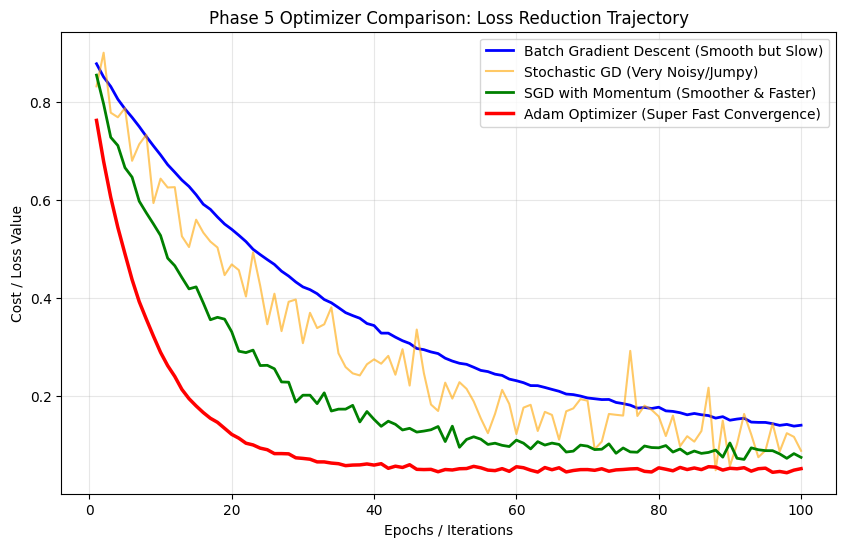

In [9]:
import numpy as np
import matplotlib.pyplot as plt

epochs = 100
t = np.arange(1, epochs + 1)

loss_batch_gd = 0.8 * np.exp(-0.03 * t) + 0.1 + np.random.normal(0, 0.002, epochs)
loss_sgd = 0.8 * np.exp(-0.04 * t) + 0.1 + np.random.normal(0, 0.04, epochs)
loss_momentum = 0.8 * np.exp(-0.06 * t) + 0.08 + np.random.normal(0, 0.01, epochs)
loss_adam = 0.8 * np.exp(-0.12 * t) + 0.05 + np.random.normal(0, 0.003, epochs)

plt.figure(figsize=(10, 6))
plt.plot(t, loss_batch_gd, label='Batch Gradient Descent (Smooth but Slow)', color='blue', lw=2)
plt.plot(t, loss_sgd, label='Stochastic GD (Very Noisy/Jumpy)', color='orange', alpha=0.6)
plt.plot(t, loss_momentum, label='SGD with Momentum (Smoother & Faster)', color='green', lw=2)
plt.plot(t, loss_adam, label='Adam Optimizer (Super Fast Convergence)', color='red', lw=2.5)

plt.title('Phase 5 Optimizer Comparison: Loss Reduction Trajectory')
plt.xlabel('Epochs / Iterations')
plt.ylabel('Cost / Loss Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Visualizing Overfitting & Regularization Control

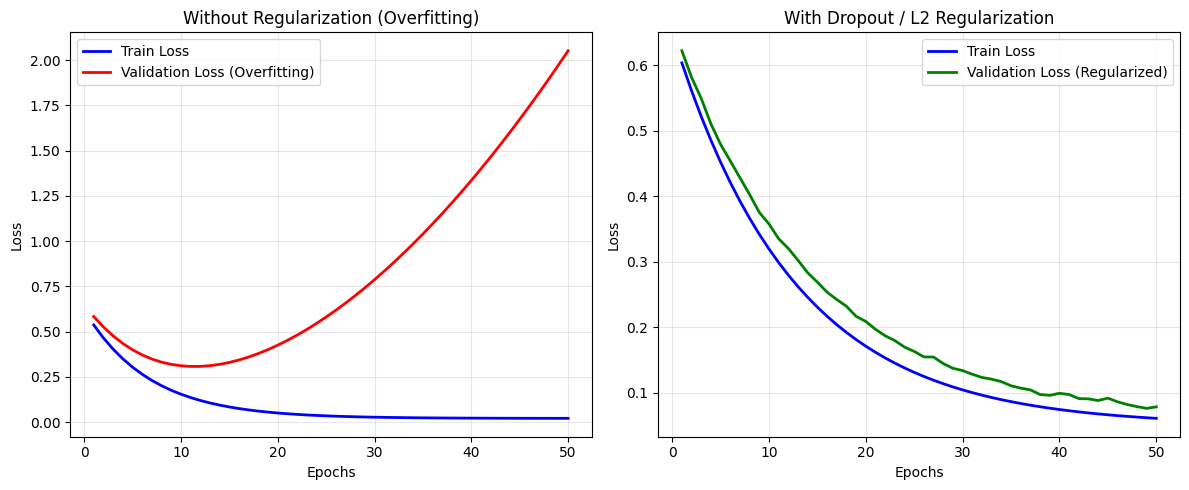

In [10]:
import numpy as np
import matplotlib.pyplot as plt

epochs = 50
t = np.arange(1, epochs + 1)

train_loss_overfit = 0.6 * np.exp(-0.15 * t) + 0.02
val_loss_overfit = 0.6 * np.exp(-0.12 * t) + 0.05 + 0.0008 * (t ** 2)

train_loss_reg = 0.6 * np.exp(-0.08 * t) + 0.05
val_loss_reg = 0.6 * np.exp(-0.07 * t) + 0.06 + np.random.normal(0, 0.002, epochs)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t, train_loss_overfit, label='Train Loss', color='blue', lw=2)
plt.plot(t, val_loss_overfit, label='Validation Loss (Overfitting)', color='red', lw=2)
plt.title('Without Regularization (Overfitting)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(t, train_loss_reg, label='Train Loss', color='blue', lw=2)
plt.plot(t, val_loss_reg, label='Validation Loss (Regularized)', color='green', lw=2)
plt.title('With Dropout / L2 Regularization')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
